<a href="https://colab.research.google.com/github/AlejandroBlandonV/connectaTel-analysis/blob/main/connectaTel_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()
# Se deben convertir las columnas ['reg_date','churn_date'] a DATETIME
#En Columnas como 'city' y 'churn_date' hay valores NAns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()
# Convertir a datetime 'date'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print('Cantidad de nulos para users:')
print( users.isna().sum())
print()
print('Proporción de valores nulos en users:')
print(users.isna().mean())

Cantidad de nulos para users:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos en users:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print('Cantidad de nulos para usage:')
print( usage.isna().sum())
print()
print('Proporción de valores nulos en usage:')
print(usage.isna().mean())

Cantidad de nulos para usage:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos en usage:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64



 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
-
En la Tabla users se hallan las siguientes columnas con valores faltantes: 'city' con 11% de faltantes, se toma la decisión de no eliminar e imputar en los '?' con 'Pd.NA'. Y la columna 'churn_date' con un 88.35% se decide mantener los nulos y analizarlos para una posible imputación.

- En la tabla usage se observan 3 columnas con nulos. La primera, 'date' con un 0.125%, se decide eliminar esos valores ya que son mínimos y no afectan el análisis. En 'duration' con 55.19%, se debe investigar su patrón, para decidir si imputar, al igual con 'length' con un 44.74%.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users[['user_id','age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` no se ven anomalías en los datos, puesto que es un valor que representa al usuario. No se identifican valores nulos ni en los mínimos ni en los máximos.
- La columna `age` se observa un valor inválido en la edad mínima de los usuarios, se identifica el[-999]). La desviación estándar se ve afectada posiblemente por este valor inválido. Se tomarán decisiones de imputación para mejorar la calidad de la columna y no afectar el análisis.

In [ ]:
# explorar columnas numéricas de usage
usage[['id','user_id']].describe()

,id,user_id
count,40000.00000,40000.000000
mean,20000.50000,12002.405975
std,11547.14972,1157.279564
min,1.00000,10000.000000
25%,10000.75000,10996.000000
50%,20000.50000,12013.000000
75%,30000.25000,13005.000000
max,40000.00000,13999.000000


- Las columnas `id` y `user_id`son identificardores de registros, lo cual no aporta insights de negocio. Además, no se observan valores faltantes ni outliers, y su mero propósito es conectar Tablas.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


In [ ]:
users['city'].unique()

array(['Medellín', '?', 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

- La columna `city` tiene valores ausentes e inválidos. La ciudad con mayor aparición en el dataset es Bogotá con 808 apariciones
- La columna `plan` no tiene valores ausentes ni nulos, y el Plan con mayor aparición es el Básico con 2595.

In [ ]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

In [ ]:
usage['type'].unique()

array(['call', 'text'], dtype=object)

- La columna `type` no tiene ausentes ni inválidos, el tipo de mensajes con mayor frecuencia es de 'text' con 22092.


---
**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- En 'city' se observa el sentinel '?' y valores inválidos y en 'age' valor inválido '-999'
- Imputación en 'city' con un fillna('PD.NA') y en 'age' validar e imputar con mediana o media sea el caso.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna `churn_date` de users
users['churn_date'] = pd.to_datetime(users['churn_date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()

array([2022, 2026, 2023, 2024])

En `reg_date`, se observa años fuera del análisis '2026', se debe eliminar las filas que tengan este año

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.unique()

array([2024.,   nan])

In [ ]:
usage=usage.dropna(subset=['date']).reset_index(drop=True)
usage['date'].dt.year.unique()

array([2024])

En `date`, está el año a analizar y hay existencias de Nans, pero se decidió desde un principio que los Nans se van a eliminar.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:

# Reemplazar ? por NA en city
users['city']=users['city'].replace('?',pd.NA)
users['city'] = users['city'].fillna(pd.NA)

# Verificar cambios
users['city'].describe()
users['city'].unique()


array(['Medellín', <NA>, 'CDMX', 'Bogotá', 'GDL', 'MTY', 'Cali'],
      dtype=object)

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.unique()

array([2022.,   nan, 2023., 2024.])

In [ ]:
# Se eliminan las columnas nan con dropna
users=users.dropna(subset=['reg_date']).reset_index(drop=True)
users['reg_date'].dt.year.unique()

array([2022, 2023, 2024])

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values()

type
call    0.000000
text    0.999275
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values()

type
text    0.000000
call    0.999329
Name: length, dtype: float64

- Encontramos que ambas columnas ['duration', 'length'] sí concentran las mayoría de los valores faltantes por el lado de 'duration' la categoría text concentra 99.92%. Mientras que en 'length', la categoría call el 99.93%. Esto quiere decir que son MAR (Missing At Random), por lo que para el análisis se dejaran como Nulos, para no eliminar datos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas
2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


In [ ]:
# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',           # Total de mensajes
    'is_call': 'sum',           # Total de llamadas
    'duration': 'sum'           # Total de minutos de llamadas
}).reset_index().rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

usage_agg['cant_minutos_llamada'] = usage_agg['cant_minutos_llamada'].fillna(0)

# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on = 'user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaT,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile.info()
columnas_numericas_up=['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']
user_profile[columnas_numericas_up].describe()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3960 entries, 0 to 3959
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   user_id               3960 non-null   int64         
 1   first_name            3960 non-null   object        
 2   last_name             3960 non-null   object        
 3   age                   3960 non-null   float64       
 4   city                  3398 non-null   object        
 5   reg_date              3960 non-null   datetime64[ns]
 6   plan                  3960 non-null   object        
 7   churn_date            0 non-null      datetime64[ns]
 8   cant_mensajes         3959 non-null   float64       
 9   cant_llamadas         3959 non-null   float64       
 10  cant_minutos_llamada  3959 non-null   float64       
dtypes: datetime64[ns](2), float64(4), int64(1), object(4)
memory usage: 371.2+ KB


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3960.000000,3959.000000,3959.000000,3959.000000
mean,48.105808,5.519323,4.477393,23.304036
std,17.687434,2.359132,2.141633,18.191896
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.085000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.340000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Los nulos son informativos - representan clientes activos
user_profile['churn_status'] = user_profile['churn_date'].isna().map({
    True: 'Activo',
    False: 'Churn'
})

In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.649747
Premium    0.350253
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

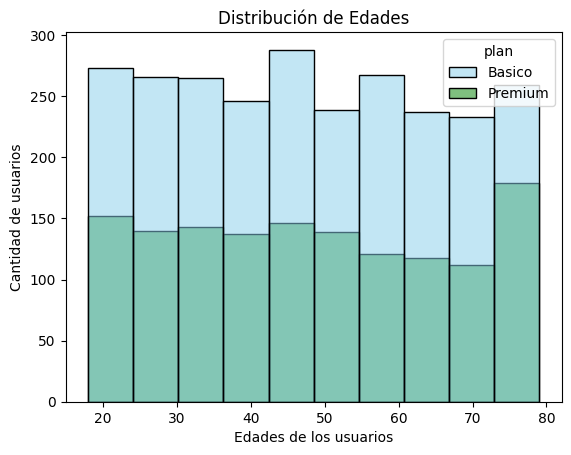

In [ ]:
# Histograma para visualizar la edad (age)

sns.histplot(data=user_profile, x='age', hue='plan', bins=10, palette=['skyblue','green'])
plt.xlabel('Edades de los usuarios')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de Edades')
plt.show()


💡Insights:
- Distribución de los datos es Normal, no se ven sesgos ni outliers, el plan Premium tiene una alta demanda en los clientes entre los 73 y 80 años.

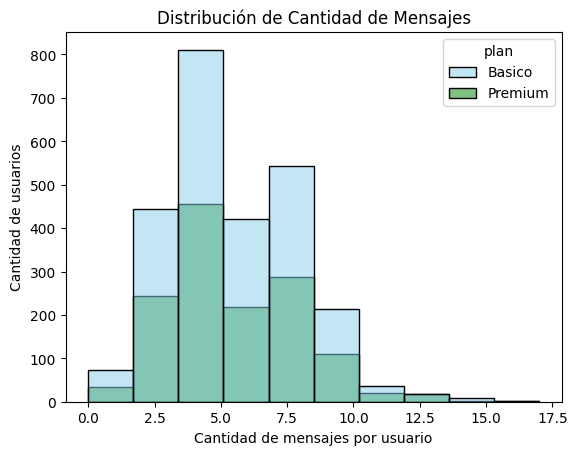

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=10, palette=['skyblue','green'])
plt.xlabel('Cantidad de mensajes por usuario')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de Cantidad de Mensajes')
plt.show()


💡Insights:
- Right-Skewed Distribution: La mayoría de mensajes ronda entre los 2.5 a 7.5 mensajes por usuario, pero se ve en la distribución una pequeña extensión hacia la derecha en los que los usuarios con plan Premium realizan mas de 12.5 mensajes

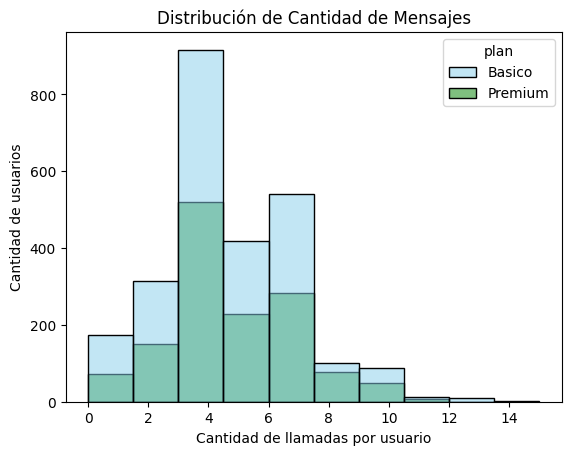

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=10, palette=['skyblue','green'])
plt.xlabel('Cantidad de llamadas por usuario')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de Cantidad de Mensajes')
plt.show()


💡Insights:
- Distribución muy similar a la de Cantidad de Mensajes, se sesga hacia la derecha. La mayoría de llamadas por usuario oscilan entre las 2 y 6 llamadas, con alargamientos de 8 a 14 por parte de ambos planes

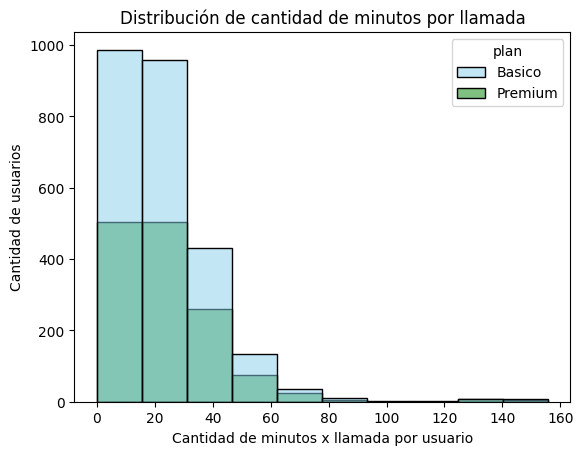

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=10, palette=['skyblue','green'])
plt.xlabel('Cantidad de minutos x llamada por usuario')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de cantidad de minutos por llamada')
plt.show()

💡Insights:
- Distribución totalmente sesgada a la derecha. Se observan valores atípicos lo que lo más seguro esté afectando a la media de la variable

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

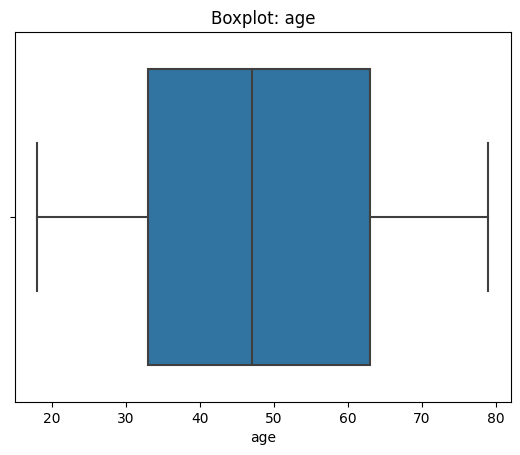

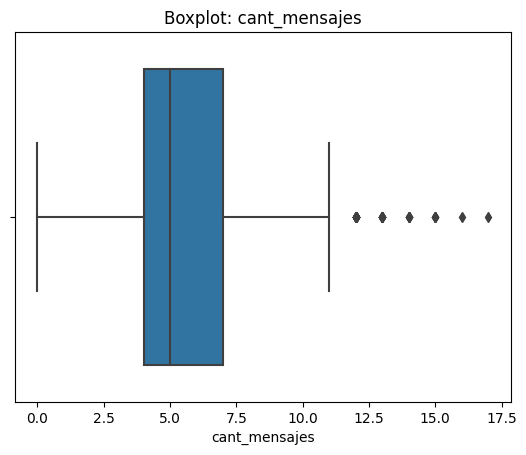

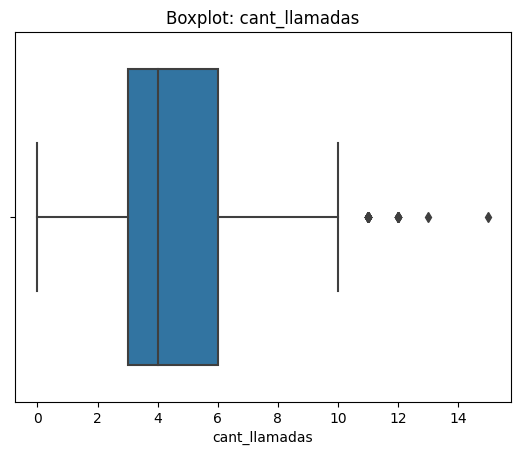

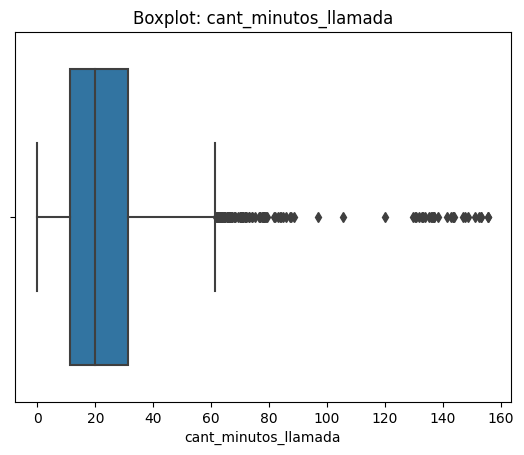

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:
- Age: no presenta outliers, y sus bigotes son proporcionales visualmente.
- cant_mensajes: Presenta diversos outliers
- cant_llamadas: Presenta varios outliers, revisar su naturaleza
- cant_minutos_llamada: Presenta muchos outliers, revisar si se eliminan o winsorizan

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes','cant_llamadas','cant_minutos_llamada']
for col in columnas_limites:
    Q1= user_profile[col].quantile(0.25)
    Q3=user_profile[col].quantile(0.75)
    IQR=Q3-Q1
    lower= Q1-1.*IQR
    upper=Q3 + 1.5*IQR
    print(f'Límites en {col}')
    print('Límite inferior: ',lower)
    print('Límite superior: ',upper)
    print()



Límites en cant_mensajes
Límite inferior:  1.0
Límite superior:  11.5

Límites en cant_llamadas
Límite inferior:  0.0
Límite superior:  10.5

Límites en cant_minutos_llamada
Límite inferior:  -9.170000000000002
Límite superior:  61.72250000000001



In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3959.000000,3959.000000,3959.000000
mean,5.519323,4.477393,23.304036
std,2.359132,2.141633,18.191896
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.085000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.340000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes  Decisión: MANTENER (17 mensajes es realista para un usuario activo)
- cant_llamadas Decisión: MANTENER (15 llamadas es posible para usuarios frecuentes)
- cant_minutos_llamada: Decisión: EVALUAR (155 minutos podría ser real, pero revisar si son muchos casos)

In [ ]:
# Contar outliers
outliers_superiores = (user_profile['cant_minutos_llamada'] > upper).sum()
outliers_inferiores = (user_profile['cant_minutos_llamada'] < lower).sum()
total_outliers = outliers_superiores + outliers_inferiores

print(f'Outliers superiores (> {upper:.2f}): {outliers_superiores}')
print(f'Outliers inferiores (< {lower:.2f}): {outliers_inferiores}')
print(f'Total de outliers: {total_outliers}')
print(f'Porcentaje de outliers: {(total_outliers/len(user_profile))*100:.2f}%')

Outliers superiores (> 61.72): 110
Outliers inferiores (< -9.17): 0
Total de outliers: 110
Porcentaje de outliers: 2.78%


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def classify_uso(row):
    llamadas=row['cant_llamadas']
    mensajes=row['cant_mensajes']
    if pd.isna(llamadas) or pd.isna(mensajes):
        return "Error en Datos"
    if llamadas < 5 and mensajes <5:
        return 'Bajo uso'
    elif llamadas<10 and mensajes<10:
        return 'Uso medio'
    else:
        return 'Alto uso'
user_profile['grupo_uso']=user_profile.apply(classify_uso, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,churn_status,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,7.0,3.0,23.70,Activo,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaT,5.0,10.0,33.18,Activo,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,5.0,2.0,10.74,Activo,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,11.0,3.0,8.99,Activo,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,4.0,3.0,8.01,Activo,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def classify_edad(row):
    age=row['age']
    if pd.isna(age):
        return "Error en Datos"
    if age < 30 :
        return 'Joven'
    elif age< 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'
user_profile['grupo_edad']=user_profile.apply(classify_edad, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,churn_status,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,7.0,3.0,23.70,Activo,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaT,5.0,10.0,33.18,Activo,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,5.0,2.0,10.74,Activo,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,11.0,3.0,8.99,Activo,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,4.0,3.0,8.01,Activo,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

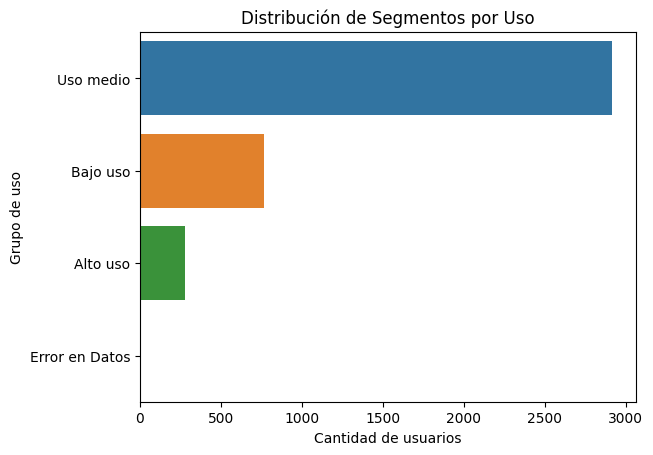

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, y= 'grupo_uso', order= user_profile['grupo_uso'].value_counts().index)
plt.title("Distribución de Segmentos por Uso")
plt.xlabel('Cantidad de usuarios')
plt.ylabel('Grupo de uso')
plt.show()

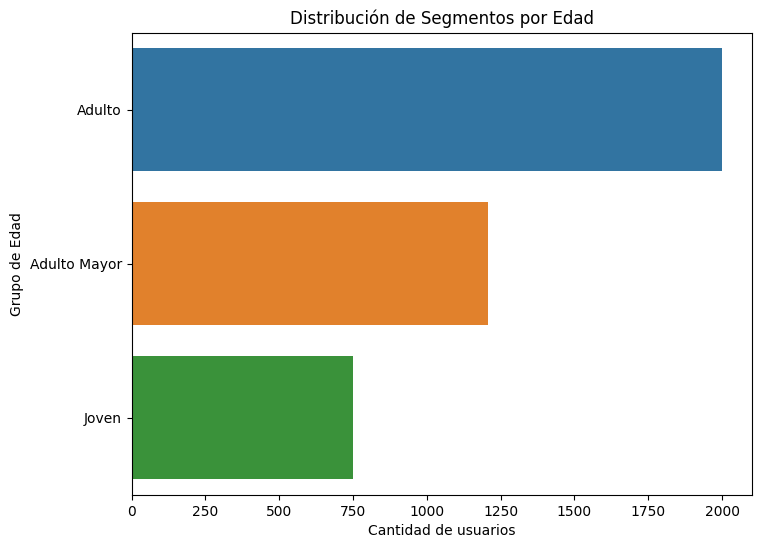

In [ ]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 6))
ax=sns.countplot(data=user_profile, y= 'grupo_edad', order= user_profile['grupo_edad'].value_counts().index)
plt.title("Distribución de Segmentos por Edad")
plt.xlabel('Cantidad de usuarios')
plt.ylabel('Grupo de Edad')
plt.show()



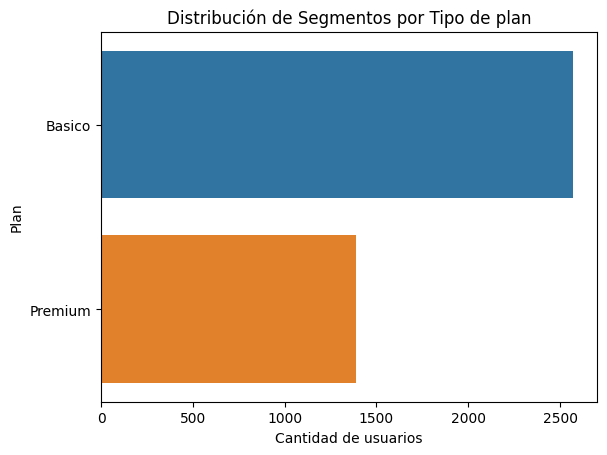

In [ ]:
sns.countplot(data=user_profile, y= 'plan', order= user_profile['plan'].value_counts().index)
plt.title("Usuarios por Tipo de plan")
plt.xlabel('Cantidad de usuarios')
plt.ylabel('Plan')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- En la Tabla **users** se hallan las siguientes columnas con valores faltantes: 'city' con 11% de faltantes, se toma la decisión de no eliminar e imputar en los '?' con 'Pd.NA'. Y la columna 'churn_date' con un 88.35% se decide mantener los nulos ya que es la fecha en la que usuario abandona el plan, por lo que tiene sentido que sean tantos nulos.

- En la tabla **usage** se observan 3 columnas con nulos. La primera, 'date' con un 0.125%, se decide eliminar esos valores ya que son mínimos y no afectan el análisis. En 'duration' con 55.19%, se debe investigar su patrón, para decidir si imputar, al igual con 'length' con un 44.74%. Luego de analizar se verificaron y ambos son MAR por lo que se mantienen como nulos.

- En la columna 'age' de **users** se identificó valores inválidos en la edad mínima [-999], se imputó la mediana de esa columna para evitar errores en el análisis.

- En ambas Tablas se modificaron columnas que representan fechas y tenian formato object con pd_todatetime a fecha


🔍 **Segmentos por Edad**
- Para ConnectaTel el usuario adulto es el más importante ya que es el más representativo y con mayor cantidad de los tres tipos de Usuario, cuenta con el 50% de usuarios con edades entre los 30 y 59 años.
- El usuario Joven es con el que ConnectaTel no tiene tan buena "relacion" ya que solo se cuenta con 750 usuarios que es menos del 20% del total.


📊 **Segmentos por Nivel de Uso**
- Se observa que en el gráfico de Segmentación por uso, casi tres mil usuarios clasifican como 'Uso medio' con la condición asignada, con valores que oscilan entre los 5 y 9 mensajes y llamadas por usuario.
- Por otro lado, menos de 500 usuarios le dan un 'Alto uso' a su plan (sea Premium o Básico), siendo el peor de los 3 segmentos, esto quiere decir, que muy pocos usuarios realizan 10 o más llamadas y envían 10 o más mensajes.
- Finalmente, se agregó un gráfico para observar que plan es el más usado por los usuarios, el cual fue el Básico, alrededor del 68% de los usuarios lo usan mientras que el Premium fue del 31%.

Todo este análisis sugiere las siguientes recomendaciones:
- Considerando la época y la generación actual, la empresa ConnectaTel debe realizar campañas para mejorar la relación con los usuarios jóvenes ya que son los que mayor consumen tecnología en la hoy en día. Estudiar más a fondo el comportamiento de este tipo de Usuarios con encuestas, pruebas gratis o descuentos.
- Por el lado de los usuarios Adultos, tratar de hacer lo mismo que los anteriores y comprender más a fondo su comportamiento, esto para mantenerlos fieles a la empresa. La fidelidad se puede formalizar con el historial de permanecia de cada usuario, brindando mejores precios de plan, descuentos o incluso crear beneficios relacionados con otro tipo de empresas.
- Se recomienda hacer una revisión exhaustiva para esos valores extremadamente altos en la cantidad de minutos por llamada, ya que pueden ser fraude, error de digitación y registro, o un comportamiento inusual. Revisar aquellos usuarios con estos valores, revisar su historial y tomar acción.
- Comparar los costos de ambos planes, ¿es posible reducir el Premium para captar más clientes?
  que tanta diferencia hay en los beneficios de un plan con otro? Decidir por mejor margen o mejor cantidad.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`